<a href="https://colab.research.google.com/github/connectnganhuynh1-ops/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

In [54]:
!git clone https://github.com/ds4e/undergrad_ml_assignments.git

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Answer for Q1.1:**

A model is considered linear when it is linear in the coefficients (parameters), not necessarily in the variables themselves. This means the model can be written as a weighted sum of features plus an intercept. Even if the features are transformed such as squared terms or logs, the model is still linear as long as the coefficients multiply the features directly and are not inside nonlinear functions.

**Answer for Q1.2:**

The coefficient of a dummy variable represents the difference in the predicted outcome relative to the reference (omitted) category, holding all other variables constant. The intercept corresponds to the baseline group, when all dummy variables are 0. Each dummy coefficient shows how much the prediction changes when that category is present compared to the baseline.

**Answer for Q1.3:**

Linear regression can be used for classification by predicting values and applying a threshold (like 0.5); however, it is not ideal. Linear regression assumes a continuous outcome and can produce predictions outside the range of 0 and 1, which doesn't make sense for probabilities. Classification models like logistic regression are preferred because they constrain predictions to valid probabilities and better model class boundaries.

**Answer for Q1.4:**

Signs of overfitting include: a very high performance on training data but poor performance on test data, a large variance in coefficients, when the model becomes sensitive to small changes in data, adding more variables can also improve training error but not test error, and a complex model with many predictors relative to sample size.

**Answer for Q1.5:**

Multicollinearity occurs when one predictor variable can be highly explained by other predictors, making it difficult to estimate individual coefficients. In two-stage least squares, we first regress the collinear variable on the other predictors and obtain predicted values. In the second stage, we use these predicted values instead of the original variable in the regression. This isolates the independent variation in the variable and reduces instability caused by multicollinearity.

**Answer for Q1.6:**

Nonlinear relationships can be incorporated by transforming the features. This includes adding polynomial terms such as x^2 and x^3, interaction terms, logarithmic transformations, or using basis expansions such as splines. These transformations allow the model to capture curvature while still remaining linear in the coefficients.

**Answer for Q1.7:**

The slope coefficient shows how much the dependent variable is expected to change when the predictor increases by one unit, while all other variables are held constant. It measures the marginal effect of that variable on the outcome.


**Answer for Q1.8:**

A train/test split divides the dataset once into a training set and a testing set. The model is trained on the training data and evaluated on the test data. This method is simple; however, results can depend heavily on how the split is chosen.

k-fold cross validation divides the data into k equal parts. The model is trained k times, each time using a different fold as the test set and the remaining folds as training data. The results are averaged across all folds, which provides a more reliable estimate of model performance.

**Answer for Q1.9:**

The value of k is usually chosen based on a trade-off between bias and computation time. Some common choices are k = 5 or k = 10, which provide a good balance between reliable performance estimates and computational efficiency. Larger k reduces bias but increases computation time.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

In [56]:
df = pd.read_csv('./undergrad_ml_assignments/data/Q1_clean.csv')

df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [57]:
df.columns = df.columns.str.strip()

In [58]:
df.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')

In [59]:
# Q2.1

df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


**Answer for Q2.1:**

Manhattan has the highest prices among the boroughs. The original price distribution is right-skewed, so a few extremely expensive listings raise the mean. Applying the log transformation compresses those large values, making the distribution more balanced and closer to normal, which is more suitable for regression modeling.

In [60]:
# Q2.1
df["log_price"] = np.log(df["Price"])

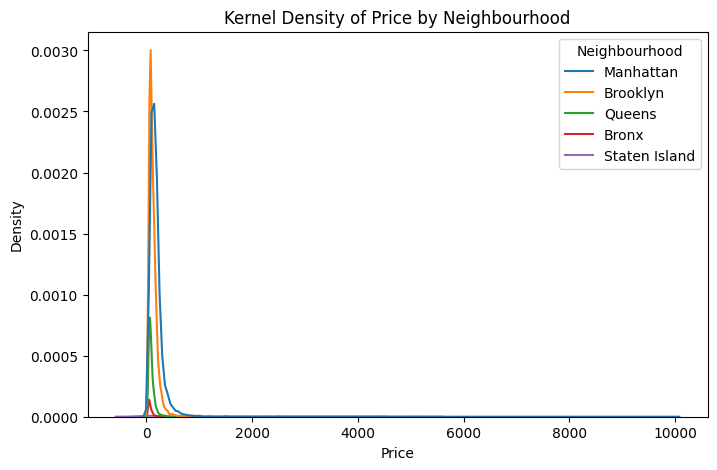

In [61]:
# Q2.1

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='Price', hue='Neighbourhood')
plt.title('Kernel Density of Price by Neighbourhood')
plt.show()

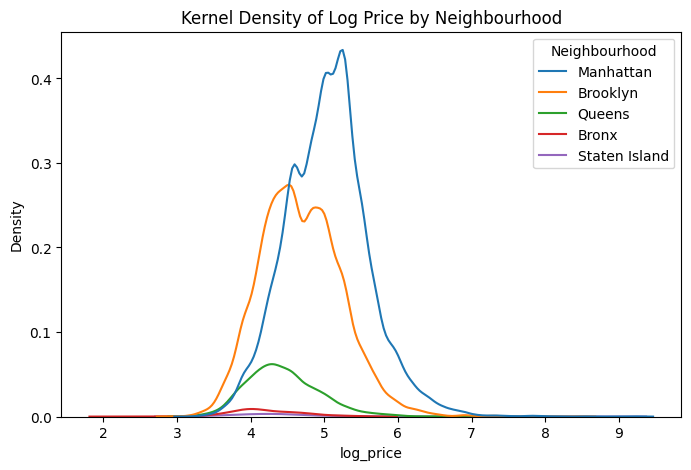

In [62]:
# Q2.1

# Log price
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='log_price', hue='Neighbourhood')
plt.title('Kernel Density of Log Price by Neighbourhood')
plt.show()

The log transformation reduces skewness and makes the distributions more comparable across neighbourhoods.

In [63]:
import statsmodels.api as sm

# creating dummies
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)

# converting
dummies = dummies.astype(float)

# ensure y is numeric
y = pd.to_numeric(df['Price'], errors='coerce')

# drop any missing values
data = pd.concat([y, dummies], axis=1).dropna()

y = data['Price']
X = data.drop(columns=['Price'])

# add constant
X = sm.add_constant(X)

model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        02:13:29   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

**Answer for Q2.2:**
I addressed the dummy variable trap by dropping the first neighborhood and keeping the intercept in the regression. That means one borough is treated as the baseline group, and everything is compared to it.

When I compare the regression coefficients to the table from part 1, they match up but are just written differently. The intercept is the average price of the baseline neighborhood, and each coefficient shows how much more or less expensive the other neighborhoods are compared to that baseline.

The conditional group means and the coefficients are directly related. You can recover the average price for any neighborhood by taking the intercept and adding that neighborhood’s coefficient. So overall, the regression is basically just another way of expressing the group averages, but in terms of differences from the baseline.

In [64]:
# Q2.3
X = sm.add_constant(df['Review Scores Rating'])
y = df['Price']

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        02:13:29   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

**Answer for Q2.3:**
The slope coefficient on Review Scores Rating is approximately 1.02, meaning that a one-point increase in rating is associated with about a $1.02 increase in nightly price on average. Although this effect is statistically significant, the R-squared is very low (0.004), indicating that review scores explain very little of the variation in price. This suggests that other factors, such as location, are likely much more important in determining price.

In [65]:
# Q2.4

X = pd.concat([dummies, df['Review Scores Rating']], axis=1)
X = sm.add_constant(X)

model3 = sm.OLS(y, X).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        02:13:29   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

**Answer for Q2.4:**

After including neighborhood controls, the coefficient on Review Scores Rating increases slightly from about 1.02 to 1.08, suggesting that controlling for location strengthens the estimated relationship between ratings and price. This indicates that the earlier model may have suffered from omitted variable bias. The neighborhood coefficients now measure differences in price relative to the baseline neighborhood while holding review scores constant, rather than simple differences in group averages.

In [66]:
# Q2.5

# creating dummies
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True).astype(float)

# base rating variable
rating = df['Review Scores Rating']

# interaction terms
interactions = dummies.multiply(rating, axis=0)
interactions.columns = [col + '_x_rating' for col in dummies.columns]

# combining
X = pd.concat([rating, dummies, interactions], axis=1)
X = sm.add_constant(X)

y = df['Price']

model4 = sm.OLS(y, X).fit()
print(model4.summary())



                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        02:13:29   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     22

**Answer for Q2.5:**

The slopes are generally similar across neighborhoods such as Brooklyn, Manhattan, and Queens, since their interaction coefficients are small and not statistically significant. This indicates that review scores have a similar effect on price in most areas. However, Staten Island is an exception, with a large negative and significant interaction term, suggesting a very different relationship. Overall, the slopes are mostly similar across neighborhoods, with Staten Island as a clear outlier.

In [67]:
# Q2.6

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Model 2: Rating only
X2 = df[['Review Scores Rating']]
y = df['Price']

# Model 3: Rating + neighborhood
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True)
X3 = pd.concat([df[['Review Scores Rating']], dummies], axis=1)

# Model 4: Rating + neighborhood + interactions
interactions = dummies.multiply(df['Review Scores Rating'], axis=0)
interactions.columns = [col + '_x_rating' for col in dummies.columns]

X4 = pd.concat([df[['Review Scores Rating']], dummies, interactions], axis=1)

# Initializing
lr = LinearRegression()

# Cross-validation
cv2 = -cross_val_score(lr, X2, y, cv=5, scoring='neg_mean_squared_error').mean()
cv3 = -cross_val_score(lr, X3, y, cv=5, scoring='neg_mean_squared_error').mean()
cv4 = -cross_val_score(lr, X4, y, cv=5, scoring='neg_mean_squared_error').mean()

print("Model 2 MSE:", cv2)
print("Model 3 MSE:", cv3)
print("Model 4 MSE:", cv4)

Model 2 MSE: 22102.830156262135
Model 3 MSE: 21113.112422262097
Model 4 MSE: 21418.246870450406


**Answer for Q2.6**

Model 3 has the lowest cross-validated mean squared error (MSE ≈ 21113), indicating it provides the best predictive performance among the three models.

Comparing Model 2 and Model 3, the MSE decreases from about 22103 to 21113. This shows that including neighborhood significantly improves prediction accuracy, meaning that location is an important determinant of price.

As for Model 4, which allows the effect of review scores to vary by neighborhood, has a higher MSE (≈ 21418) than Model 3. This suggests that adding interaction terms does not improve out-of-sample performance.

Although Model 4 is more flexible, it likely overfits the training data by introducing unnecessary complexity. As a result, it performs worse on unseen data compared to the simpler Model 3.

Overall, Model 3 provides the best balance between model complexity and predictive accuracy, indicating that while both neighborhood and review scores are important predictors, allowing their relationship to vary by neighborhood is not supported by the data.



**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [68]:
# Q3.1

df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [69]:
# Q3.1

df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

By Body Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        14912

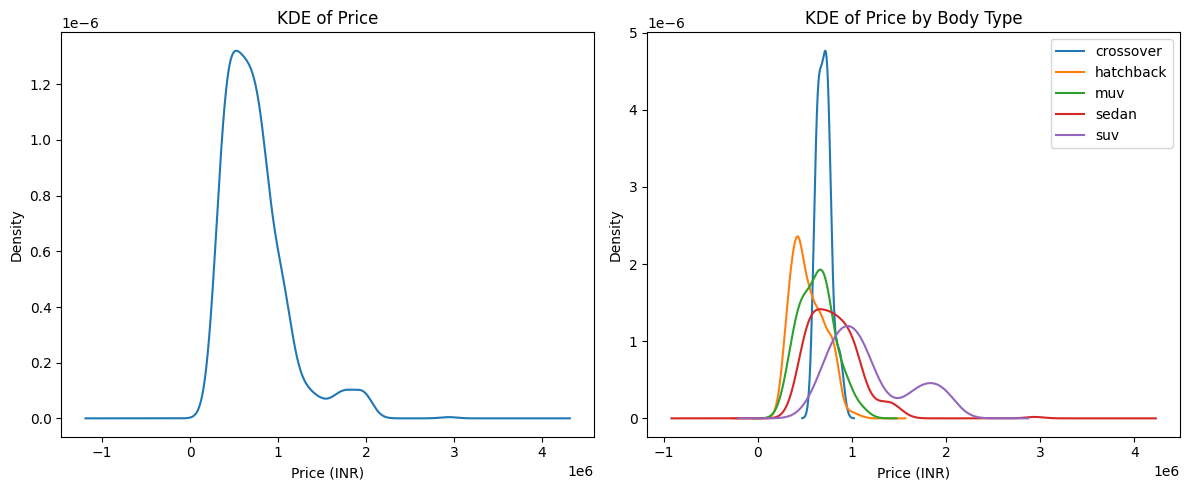

In [70]:
# Q3.1

import seaborn as sns
import matplotlib.pyplot as plt

print(df['Price'].describe())
print("\nBy Body Type:")
print(df.groupby('Body_Type')['Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Price')
axes[0].set_xlabel('Price (INR)')

for body, group in df.groupby('Body_Type'):
    group['Price'].plot.kde(ax=axes[1], label=body)
axes[1].set_title('KDE of Price by Body Type')
axes[1].set_xlabel('Price (INR)')
axes[1].legend()

plt.tight_layout()
plt.show()


**Answer for Q3.1:**

SUVs tend to be the priciest on average and show the greatest spread in prices, which is reflected by their wide, flatter KDE curve. Hatchbacks, on the other hand, are generally the least expensive and have more consistent pricing, shown by a tall, narrow KDE curve. Overall, the distribution is right-skewed, meaning most cars are relatively affordable, but a small number of high-end SUVs and sedans extend the tail to the right.

In [71]:
# Q3.2

X_cont = sm.add_constant(df['Seating_Capacity'])
model_cont = sm.OLS(df['Price'], X_cont).fit()
print(model_cont.summary())

seat_dummies = pd.get_dummies(df['Seating_Capacity'], drop_first=True).astype(int)
X_cat = sm.add_constant(seat_dummies)
model_cat = sm.OLS(df['Price'], X_cat).fit()
print(model_cat.summary())

print(df.groupby('Seating_Capacity')['Price'].mean().sort_index())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0245
Time:                        02:13:30   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

**Answer for Q3.2:**

On average, adding one more seat increases the price by about 59,270 rupees. However, when seating capacity is treated as a categorical variable, the coefficients don’t follow a linear pattern. For example, 6-seat cars are actually priced higher than 7-seat cars (1,644,000 rupees vs. 923,949 rupees). This indicates the relationship between number of seats and price isn’t truly linear, and seat count by itself is a weak predictor of price (R-squared = 0.005).

1     316694.442767
2     317513.181768
3     316828.286445
4     316977.019863
5     316435.374440
6     316777.154405
7     315926.056449
8     315198.835145
9     315657.046311
10    316066.889312
dtype: float64

Optimal degree: 8


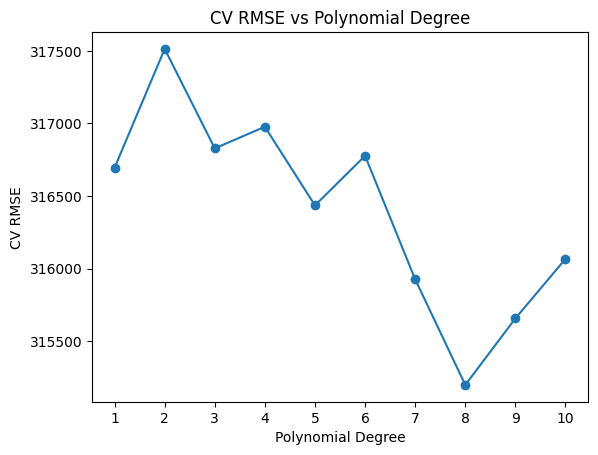

In [74]:
# Q3.3

df.columns = df.columns.str.strip()
df['Age'] = 2024 - df['Make_Year']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

cv_scores = {}

for degree in range(1, 11):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    scores = cross_val_score(model, df[['Age']], df['Price'],
                             cv=10, scoring='neg_mean_squared_error')
    cv_scores[degree] = np.sqrt(-scores.mean())

cv_df = pd.Series(cv_scores)
print(cv_df)
print(f"\nOptimal degree: {cv_df.idxmin()}")

cv_df.plot(marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV RMSE')
plt.title('CV RMSE vs Polynomial Degree')
plt.xticks(range(1, 11))
plt.show()

**Answer for Q3.3:**

With 10-fold cross-validation, a polynomial of degree 8 for Age gives the lowest CV RMSE at 315,199 INR. However, the RMSE values are very similar across all degrees (about 315,199 to 317,512), indicating that Age by itself doesn’t predict price very well. Increasing the degree just adds complexity without providing a meaningful improvement in prediction accuracy.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


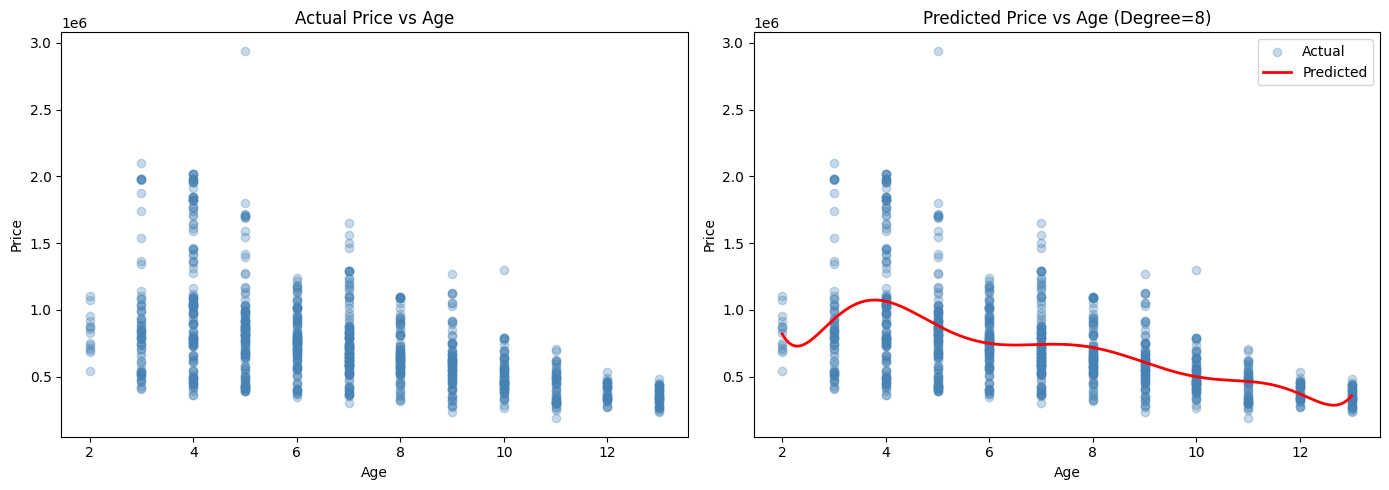

In [75]:
# Q3.4

# Fit final model with best degree
final_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('reg', LinearRegression())
])
final_pipeline.fit(df[['Age']], df['Price'])

# Smooth age range for plotting
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 300).reshape(-1, 1)
predicted_prices = final_pipeline.predict(age_range)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual
axes[0].scatter(df['Age'], df['Price'], alpha=0.3, color='steelblue')
axes[0].set_title("Actual Price vs Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Price")

# Predicted overlay
axes[1].scatter(df['Age'], df['Price'], alpha=0.3, color='steelblue', label='Actual')
axes[1].plot(age_range, predicted_prices, color='red', linewidth=2, label='Predicted')
axes[1].set_title(f"Predicted Price vs Age (Degree={best_degree})")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Price")
axes[1].legend()

plt.tight_layout()
plt.show()

**Answer for Q3.4:**

The plot indicates that car prices tend to drop as age increases, which is expected because of depreciation. However, there’s still a wide spread of prices for cars of the same age, showing that age alone isn’t a strong predictor. The degree 8 model produces a wavy curve that appears to overfit the data instead of capturing a clear trend. Overall, it is not a strong fit, suggesting that additional variables are needed to better predict price.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [76]:
df = pd.read_csv('./undergrad_ml_assignments/data/heart_hw.csv')
df.columns = df.columns.str.strip()

df['treat'] = (df['transplant'] == 'treatment').astype(int)
df.head()

,Unnamed: 0,age,transplant,y,treat
0,1,53,control,0,0
1,2,43,control,0,0
2,3,52,control,0,0
3,4,52,control,0,0
4,5,54,control,0,0


In [77]:
# Q4.1

control_mean = df[df['treat'] == 0]['y'].mean()
treatment_mean = df[df['treat'] == 1]['y'].mean()

ATE = treatment_mean - control_mean

print("Control survival rate:", control_mean)
print("Treatment survival rate:", treatment_mean)
print("ATE:", ATE)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


**Answer for Q4.1**

The survival rate in the control group (no transplant) is 11.76%, compared to 34.78% in the treatment group (received a transplant). The ATE is 0.2302, meaning that receiving a heart transplant is associated with a 23 percentage point increase in the probability of surviving three years on average.

In [78]:
# Q4.2

X = sm.add_constant(df['treat'])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        02:14:32   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

**Answer for Q4.2**

The intercept (0.1176) exactly matches the survival rate in the control group, and the coefficient on transplant (0.2302) exactly matches the ATE computed in part 1. This makes sense because with a single binary predictor, the linear regression is just recovering the group means, the intercept is the mean of the baseline group (control), and the slope is the difference in means between treatment and control (i.e., the ATE).

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        02:14:35   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

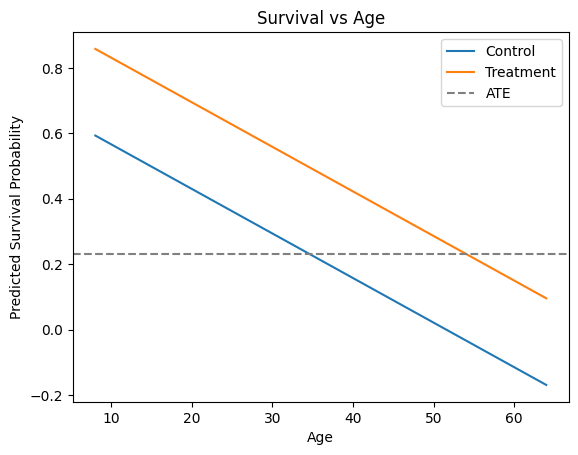

In [79]:
# Q4.3

X = sm.add_constant(df[['treat', 'age']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

age_grid = np.linspace(df['age'].min(), df['age'].max(), 100)

pred_control_df = pd.DataFrame({
    'const': 1,
    'treat': 0,
    'age': age_grid
})
pred_control = model.predict(pred_control_df)


pred_treat_df = pd.DataFrame({
    'const': 1,
    'treat': 1,
    'age': age_grid
})
pred_treat = model.predict(pred_treat_df)

plt.plot(age_grid, pred_control, label='Control')
plt.plot(age_grid, pred_treat, label='Treatment')
plt.axhline(y=ATE, linestyle='--', color='gray', label='ATE')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.legend()
plt.title('Survival vs Age')
plt.show()

**Answer for Q4.3**

After adjusting for age, the transplant coefficient increases to about 0.265, indicating that age was influencing the original estimate. The intercept corresponds to the predicted survival for a control patient at age 0, and the negative coefficient for age suggests survival decreases as age increases. The plot shows survival declining with age for both groups, while maintaining a constant difference between them. This means the ATE overstates the effect for younger patients and understates it for older patients, implying the effect changes with age.

In [80]:
# Q4.4

df['interaction'] = df['treat'] * df['age']

X = sm.add_constant(df[['treat', 'age', 'interaction']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        02:14:38   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.3549      0.280      1.269      

**Answer for Q4.4:**

Including an interaction between transplant and age changes the predictions so the treatment effect is no longer constant and instead depends on age. The model suggests that the benefit of a transplant gets smaller as age increases, meaning younger patients gain more than older patients. The gap between the treatment and control groups narrows with age, which provides a more realistic pattern than the earlier model.

In [81]:
# Q4.5

X1 = df[['treat']]

X2 = df[['treat', 'age']]

X3 = df[['treat', 'age', 'interaction']]

y = df['y']

model = LinearRegression()

cv1 = -cross_val_score(model, X1, y, cv=10, scoring='neg_mean_squared_error').mean()
cv2 = -cross_val_score(model, X2, y, cv=10, scoring='neg_mean_squared_error').mean()
cv3 = -cross_val_score(model, X3, y, cv=10, scoring='neg_mean_squared_error').mean()

print("Model 1 (treat):", cv1)
print("Model 2 (treat + age):", cv2)
print("Model 3 (interaction):", cv3)

Model 1 (treat): 0.20970277289824915
Model 2 (treat + age): 0.19922806049232317
Model 3 (interaction): 0.19609811380122735


**Answer for Q4.5:**

The model that only includes transplant has the largest error, but performance improves when age is added. The model with the interaction term has the lowest error, indicating it gives the best survival predictions. This suggests that including both age and the interaction captures more detail and leads to better predictive accuracy.

**Answer for Q4.6:**

There are several concerns about using this model to prioritize transplant access. First, the dataset is very small (103 observations), which makes the estimates unstable and unlikely to generalize well to a broader population. In addition, the linear probability model can predict survival probabilities outside the 0-1 range, which is not meaningful for a binary outcome. Thirdly, the model only includes age and transplant status, leaving out important factors like severity of illness or other health conditions that likely affect survival. On the deployment side, since the model predicts that younger patients benefit more from transplants, using it to allocate access could place a disadvantage on older patients, raising serious fairness concerns. The model is also trained on historical data that may already reflect biased decisions, in which it could perpetuate existing inequities. Lastly, there is a feedback loop risk, if the model is used to decide who gets transplants, future data will reflect those decisions rather than true patient need, making it harder to evaluate whether the model is actually working.